In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [29]:
df = pd.read_csv(r"/home/workspace/my-project/heart.csv")
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [31]:
df.shape
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [32]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

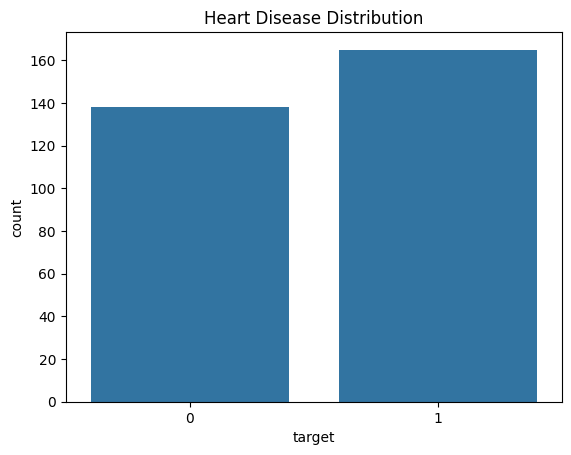

In [33]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

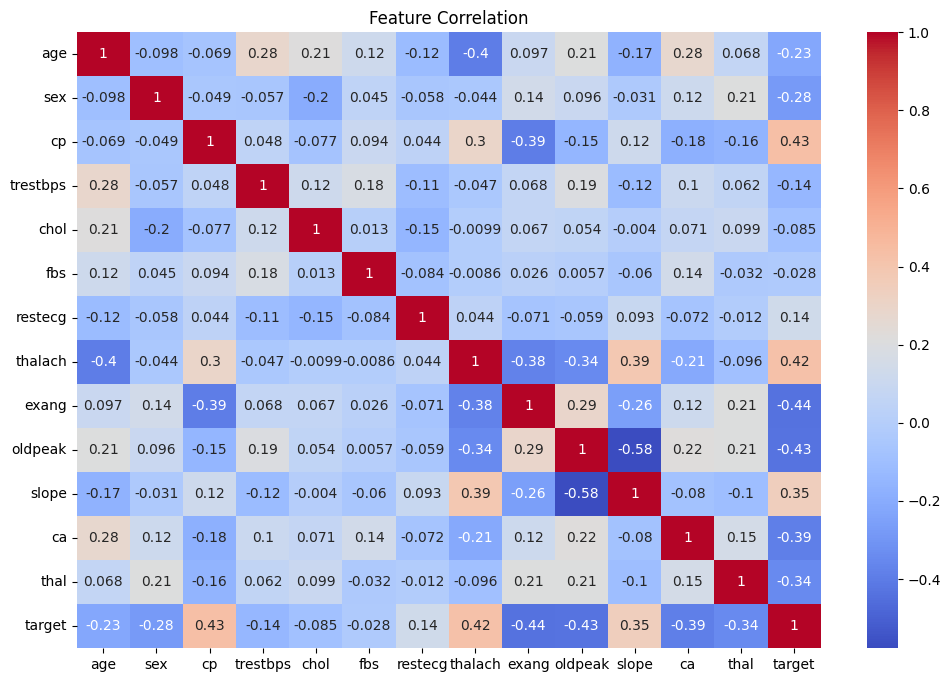

In [34]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

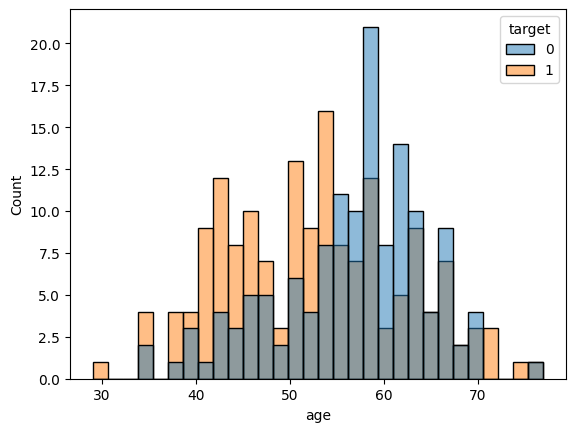

In [35]:
sns.histplot(data=df, x='age', hue='target', bins=30)
plt.show()

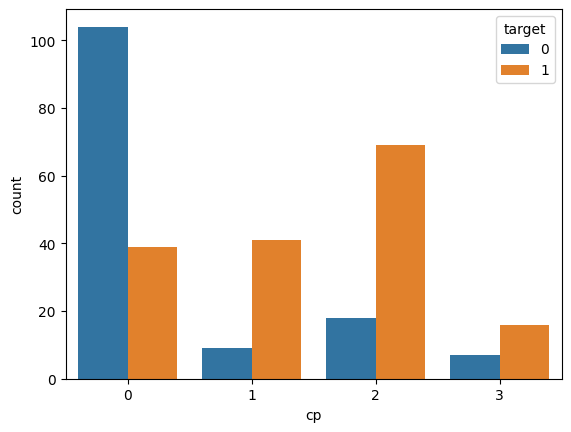

In [36]:
sns.countplot(x='cp', hue='target', data=df)
plt.show()

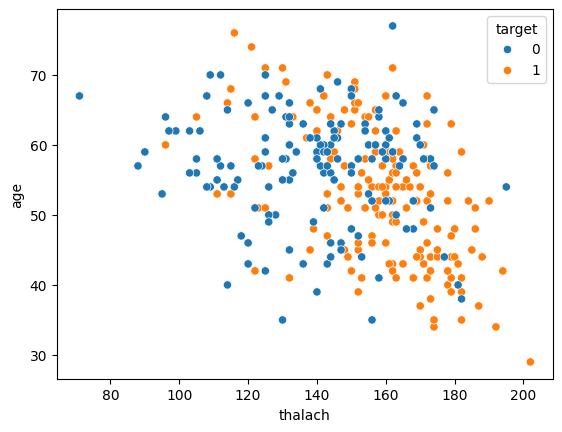

In [37]:
sns.scatterplot(x='thalach', y='age', hue='target', data=df)
plt.show()

In [38]:
X = df.drop('target', axis=1)
y = df['target']

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [41]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8524590163934426
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [42]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.8524590163934426


In [43]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8688524590163934


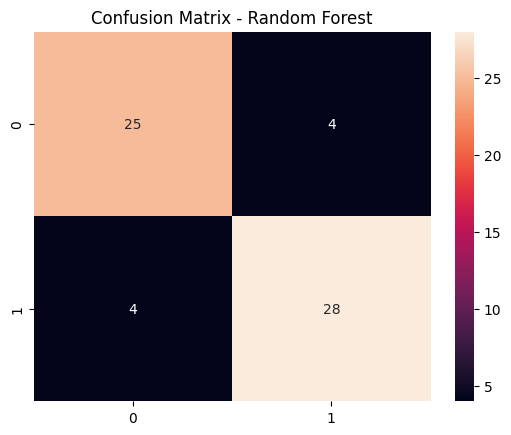

In [44]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [45]:
print("LR:", accuracy_score(y_test, y_pred_lr))
print("DT:", accuracy_score(y_test, y_pred_dt))
print("RF:", accuracy_score(y_test, y_pred_rf))

LR: 0.8524590163934426
DT: 0.8524590163934426
RF: 0.8688524590163934


In [46]:
def predict_heart_disease(input_data):
    input_data = np.array(input_data).reshape(1, -1)
    
    # scale input
    input_data = scaler.transform(input_data)
    
    prediction = rf.predict(input_data)
    
    if prediction[0] == 1:
        return "High chance of Heart Disease"
    else:
        return "Low chance of Heart Disease"

In [47]:
age = int(input("Enter age: "))
sex = int(input("Sex (1=male, 0=female): "))
cp = int(input("Chest pain type (0-3): "))
trestbps = int(input("Resting BP: "))
chol = int(input("Cholesterol: "))
fbs = int(input("Fasting sugar >120 (1/0): "))
restecg = int(input("Rest ECG (0-2): "))
thalach = int(input("Max heart rate: "))
exang = int(input("Exercise angina (1/0): "))
oldpeak = float(input("Oldpeak: "))
slope = int(input("Slope (0-2): "))
ca = int(input("Major vessels (0-4): "))
thal = int(input("Thal (0-3): "))

user_data = [age, sex, cp, trestbps, chol, fbs,
             restecg, thalach, exang, oldpeak,
             slope, ca, thal]

print(predict_heart_disease(user_data))

ValueError: invalid literal for int() with base 10: ''

In [ ]:
pip install streamlit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 69.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 KB 22.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 MB 59.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 KB 48.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.0/797.0 KB 105.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 KB 35.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 127.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.8/325.8 KB 65.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 KB 26.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.4/449.4 KB 71.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 KB 28.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 KB 40.0 MB/s eta 0:00:00


In [ ]:
import pickle

pickle.dump(rf, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [ ]:
import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open("model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

st.title("❤️ Heart Disease Prediction App")

st.write("Enter patient details:")

# Inputs
age = st.number_input("Age", 1, 120)
sex = st.selectbox("Sex", ["Female", "Male"])
cp = st.selectbox("Chest Pain Type (0-3)", [0,1,2,3])
trestbps = st.number_input("Resting Blood Pressure")
chol = st.number_input("Cholesterol")
fbs = st.selectbox("Fasting Blood Sugar > 120", [0,1])
restecg = st.selectbox("Rest ECG (0-2)", [0,1,2])
thalach = st.number_input("Max Heart Rate")
exang = st.selectbox("Exercise Induced Angina", [0,1])
oldpeak = st.number_input("Oldpeak", step=0.1)
slope = st.selectbox("Slope (0-2)", [0,1,2])
ca = st.selectbox("Major Vessels (0-4)", [0,1,2,3,4])
thal = st.selectbox("Thal (0-3)", [0,1,2,3])

# Convert inputs
sex = 1 if sex == "Male" else 0

input_data = np.array([[age, sex, cp, trestbps, chol, fbs,
                        restecg, thalach, exang, oldpeak,
                        slope, ca, thal]])

# Predict
if st.button("Predict"):
    input_scaled = scaler.transform(input_data)
    prediction = model.predict(input_scaled)

    if prediction[0] == 1:
        st.error("⚠️ High chance of Heart Disease")
    else:
        st.success("✅ Low chance of Heart Disease")

2026-04-23 11:43:46.330 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.469 
  command:

    streamlit run /usr/local/lib/python3.10/dist-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-23 11:43:46.470 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.471 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.472 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.473 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:43:46.474 Thread 'MainThread': missi

In [ ]:
st.sidebar.title("About")
st.sidebar.write("ML model to predict heart disease based on clinical features.")


2026-04-23 11:44:24.093 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:44:24.094 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:44:24.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:44:24.096 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:44:24.097 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 11:44:24.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
